In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt


import sys
from pathlib import Path

project_root = Path().resolve().parent
src_path = project_root / "src"
sys.path.append(str(src_path))

import yaml
import h5py

from training.wno_training import EmulatorWNO
from training.fno_training import EmulatorFNO

from utils.kolmogorov_loader import load_multiple_simulation

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Model import

In [13]:
emulator_rep_path = project_root / "runs_mesu" / "RE90/RE90" / "wno_emul_lvl3_lay4_db6_norm_state_seq5_perio"

with open(emulator_rep_path / "config.yaml", "r") as f:
    args = yaml.safe_load(f)

emulator = EmulatorWNO(width=args["width"],
                       level=args["level"],
                       layers=args["layers"],
                       size=args["n_dim"]*[args["res"]],
                       wavelet=args["wavelet"],
                       in_channel=args["input_dim"],
                       out_channel=args["output_dim"],
                       grid_range=args["domain_size"],
                       padding=args["padding"],
                       tau=args["tau"],
                       device=device)

emulator.load_state_dict(torch.load(emulator_rep_path / "model_weights/min_test_loss.pth", map_location=device)["model_state_dict"])
emulator = emulator.to(device)

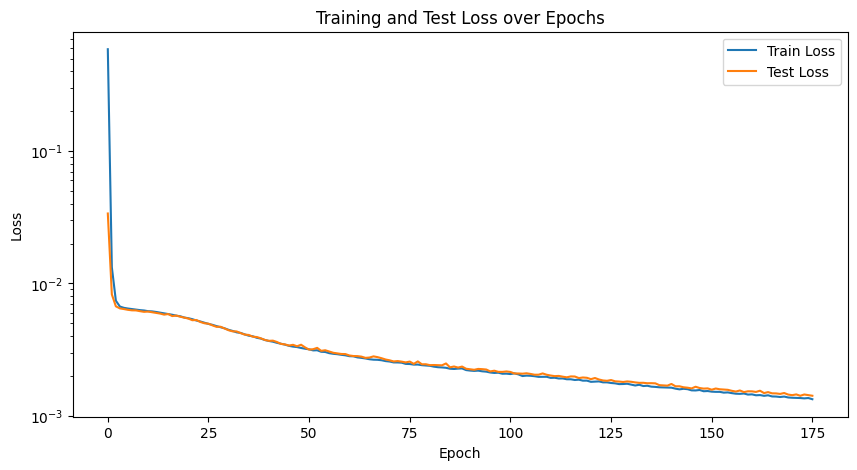

In [14]:
with open(emulator_rep_path / "logs/metrics.csv", "r") as f:
    lines = f.readlines()

header = lines[0].strip().split(",")
data = np.array([[float(v) for v in line.strip().split(",")] for line in lines[1:]])

epochs = np.arange(data.shape[0])

plt.figure(figsize=(10,5))
plt.semilogy(epochs, data[:, header.index("Tr loss")], label="Train Loss")
plt.semilogy(epochs, data[:, header.index("Te loss")], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss over Epochs")
plt.legend();

# Data importation

In [25]:
data_path = project_root / "data" / "kolmogorov" / "Re90"
train_path = data_path / "train_traj"
test_path = data_path / "test_traj"

In [34]:
data_trajectories = load_multiple_simulation(train_path, time_ds=1, space_ds=2)

In [35]:
nx, ny = data_trajectories.shape[2], data_trajectories.shape[3]

In [36]:
Re = 90
nu = 1/Re
nf = 4

In [38]:
nx,ny

(64, 64)

In [44]:
x_mean = data_trajectories.mean(axis=(0,1,2,3))
x_std = data_trajectories.std(axis=(0,1,2,3))

In [45]:
data_trajectories_norm = (data_trajectories - x_mean) / (x_std + 1e-8)

In [50]:
with torch.no_grad():
    data_torch = torch.from_numpy(data_trajectories_norm).float().to(device)
    predictions = emulator(data_torch[0]) # shape: (T, C, H, W)

In [72]:
error = torch.norm(predictions.cpu() - data_torch[0].cpu()) / torch.norm(data_torch[0].cpu())

In [73]:
error

tensor(0.0214)

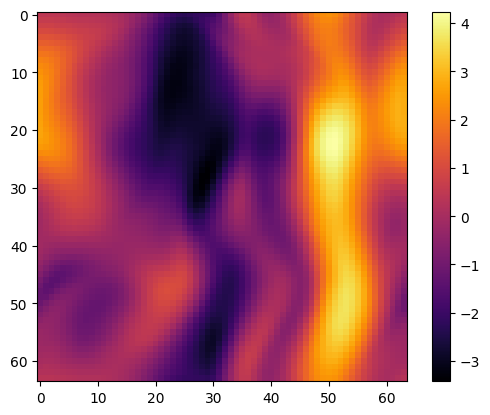

In [74]:
predictions_denorm = predictions.cpu().numpy() * (x_std + 1e-8) + x_mean
plt.imshow(predictions_denorm[-1,:,:,0], cmap="inferno")
bar = plt.colorbar()

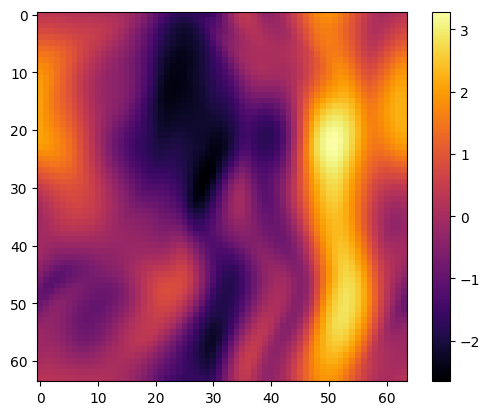

In [60]:
plt.imshow(predictions[-1,:,:,0].cpu(), cmap="inferno")
bar = plt.colorbar()

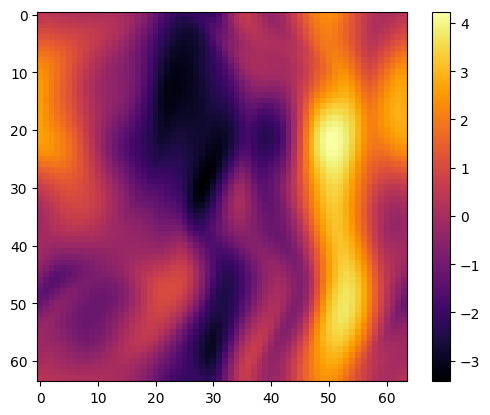

In [65]:
plt.imshow(data_trajectories[0,-1,:,:,0], cmap="inferno")
bar = plt.colorbar()

In [67]:
x_std

array([1.28944404, 1.31465633])